In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

In [2]:
df_1 = pd.read_excel('data_final_res(2015-2020)_revenue_with_null.xlsx')
df_2 = pd.read_excel('data_final_res(2020-2025)_revenue_with_null.xlsx')

list_of_dfs = [df_1, df_2]

In [3]:
df = pd.concat(list_of_dfs, ignore_index=True)

In [4]:
df.shape

(319342, 24)

In [5]:
df.head()

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Идентификационный код закупки,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,...,ИНН поставщика,Победитель,Статус допуска,"Снижение на торгах,%",Форма публикации,Тип торгов,РНП сейчас,РНП ранее,Выручка,Сводный риск
0,1,"ООО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕНИЕ ВОЛГОГРАД""",3455052505,641115.0,31907501962,NaN,[ОКПД2 71.20] Услуги в области технических исп...,Волгоградская область,Городищенский район,2019-02-07 13:30:06,...,7708825114,Победитель,Допущен,0.250002,Торговая процедура,Запрос предложений в электронной форме,0,0,20698000.0,Низкий риск
1,2,"ФБУЗ ""ЦЕНТР ГИГИЕНЫ И ЭПИДЕМИОЛОГИИ В ЧУКОТСКО...",8709010437,NaN,31907544729,NaN,"[ОКПД2 26.51] Оборудование для измерения, испы...",Чукотский автономный округ,Чукотский автономный округ,2019-02-19 17:06:02,...,6685045434,NaN,Допущен,0.086463,Торговая процедура,NaN,0,0,150848000.0,Низкий риск
2,2,"ООО ""УБО""",5837044683,NaN,31907469742,NaN,"[ОКПД2 18.12] Услуги печатные прочие, [ОКВЭД2 ...",Пензенская область,Пензенская область,2019-01-30 13:47:43,...,5835076626,NaN,Допущен,0.064138,Торговая процедура,NaN,0,0,7169000.0,Средний риск
3,2,"КОГАУСО ""МЕЖРАЙОННЫЙ КОМПЛЕКСНЫЙ ЦЕНТР СОЦИАЛЬ...",4343002226,NaN,31907592203,NaN,[ОКПД2 10.32] Продукция соковая из фруктов и о...,Кировская область,Слободской,2019-02-28 16:57:44,...,434501114310,Победитель,Допущен,0.430367,Торговая процедура,NaN,0,0,NaN,NaN
4,2,"ГУП РК ""КРЫМСКОЕ МППЖТ""",9102170826,NaN,31907416589,NaN,[ОКПД2 38.12] Отходы опасные; услуги по сбору ...,Республика Крым,Республика Крым,2019-01-15 16:30:24,...,2323021097,NaN,Допущен,0.262820,Торговая процедура,NaN,0,0,378450000.0,Низкий риск


In [6]:
print(df['Регион поставки'].unique())

['Волгоградская область' 'Чукотский автономный округ' 'Пензенская область'
 'Кировская область' 'Республика Крым' 'Республика Башкортостан'
 'Новосибирская область' 'Республика Коми' 'Орловская область'
 'Краснодарский край' 'Тюменская область' 'Москва' 'Липецкая область'
 'Ямало-Ненецкий автономный округ (Тюменская область)'
 'Ханты-Мансийский автономный округ - Югра (Тюменская область)'
 'Омская область' 'Республика Хакасия' 'Иркутская область'
 'Самарская область' 'Ставропольский край' 'Архангельская область'
 'Томская область' 'Саратовская область' 'Смоленская область'
 'Московская область' 'Алтайский край' 'Челябинская область'
 'Республика Саха (Якутия)' 'Свердловская область'
 'Республика Татарстан (Татарстан)' 'Кемеровская область - Кузбасс'
 'Республика Бурятия' 'Севастополь' 'Санкт-Петербург' 'Приморский край'
 'Забайкальский край' 'Оренбургская область' 'Нижегородская область'
 'Пермский край' 'Ярославская область' 'Мурманская область'
 'Брянская область' 'Калужская область'

Видим, что есть повторяющиеся регионы в одной ячейке (разделенны точкой с запятой)

In [7]:
print("Частота встречаемости регионов:\n")
print(df['Регион поставки'].value_counts().head(30))

Частота встречаемости регионов:

Регион поставки
Москва                                                          55208
Санкт-Петербург                                                 15742
Московская область                                              13267
Республика Башкортостан                                         12857
Свердловская область                                            12263
Краснодарский край                                               8771
Иркутская область                                                7725
Челябинская область                                              7687
Нижегородская область                                            7144
Красноярский край                                                6877
Саратовская область                                              6541
Самарская область                                                6493
Ростовская область                                               6316
Новосибирская область                    

In [8]:
print(df['Регион поставки'].isnull().sum())

0


In [9]:
def split_regions(df):
    new_rows = []
    for index, row in df.iterrows():
        regions = str(row['Регион поставки']).split(';')
        regions = [region.strip() for region in regions]
        for region in regions:
            new_row = row.copy()
            new_row['Регион поставки'] = region
            new_rows.append(new_row)
    return pd.DataFrame(new_rows)

df_exploded = split_regions(df.copy())

In [10]:
print(df_exploded['Регион поставки'].unique())

['Волгоградская область' 'Чукотский автономный округ' 'Пензенская область'
 'Кировская область' 'Республика Крым' 'Республика Башкортостан'
 'Новосибирская область' 'Республика Коми' 'Орловская область'
 'Краснодарский край' 'Тюменская область' 'Москва' 'Липецкая область'
 'Ямало-Ненецкий автономный округ (Тюменская область)'
 'Ханты-Мансийский автономный округ - Югра (Тюменская область)'
 'Омская область' 'Республика Хакасия' 'Иркутская область'
 'Самарская область' 'Ставропольский край' 'Архангельская область'
 'Томская область' 'Саратовская область' 'Смоленская область'
 'Московская область' 'Алтайский край' 'Челябинская область'
 'Республика Саха (Якутия)' 'Свердловская область'
 'Республика Татарстан (Татарстан)' 'Кемеровская область - Кузбасс'
 'Республика Бурятия' 'Севастополь' 'Санкт-Петербург' 'Приморский край'
 'Забайкальский край' 'Оренбургская область' 'Нижегородская область'
 'Пермский край' 'Ярославская область' 'Мурманская область'
 'Брянская область' 'Калужская область'

In [11]:
print("Частота встречаемости регионов после разделения: \n")
print(df_exploded['Регион поставки'].value_counts().head(30))

Частота встречаемости регионов после разделения: 

Регион поставки
Москва                                                          55214
Санкт-Петербург                                                 15742
Республика Башкортостан                                         13327
Московская область                                              13267
Свердловская область                                            12268
Краснодарский край                                               8773
Иркутская область                                                7725
Челябинская область                                              7694
Нижегородская область                                            7156
Красноярский край                                                6877
Саратовская область                                              6543
Самарская область                                                6493
Ростовская область                                               6324
Новосибирская область  

In [12]:
print("Размер df начального:", df.shape)
print("Размер df после разделения регионов:", df_exploded.shape)

Размер df начального: (319342, 24)
Размер df после разделения регионов: (319774, 24)


Небольшое увеличение строк, 432 - это количество новых строк, которые появились после разделения строк с множественными регионами, то есть если в строке было 3 региона, то добавилось 2 строки

In [19]:
def analyze_region_repetitions(df):
    mask = df['Регион поставки'].str.contains(';', na=False)
    rows_with_semicolon = df[mask]
    
    analysis = []
    for idx, row in rows_with_semicolon.iterrows():
        regions = [r.strip() for r in row['Регион поставки'].split(';')]
        unique_regions = set(regions)
        
        if len(regions) != len(unique_regions):
            region_counts = {region: regions.count(region) for region in unique_regions}
            analysis.append({
                'Индекс': idx,
                'Исходная строка': row['Регион поставки'],
                'Всего регионов': len(regions),
                'Уникальных регионов': len(unique_regions),
                'Повторения': region_counts
            })
    
    return pd.DataFrame(analysis)

repetitions_df = analyze_region_repetitions(df)

print("Всего строк с повторяющимися регионами:", len(repetitions_df))
repetitions_df.head()

Всего строк с повторяющимися регионами: 168


,Индекс,Исходная строка,Всего регионов,Уникальных регионов,Повторения
0,81584,Республика Башкортостан; Республика Башкортост...,7,1,{'Республика Башкортостан': 7}
1,88697,Республика Башкортостан; Республика Башкортост...,9,1,{'Республика Башкортостан': 9}
2,93145,Республика Башкортостан; Республика Башкортостан,2,1,{'Республика Башкортостан': 2}
3,108720,Нижегородская область; Нижегородская область; ...,4,1,{'Нижегородская область': 4}
4,210758,Хабаровский край; Хабаровский край,2,1,{'Хабаровский край': 2}


In [15]:
total_duplicates = sum([row['Всего регионов'] - row['Уникальных регионов'] 
                          for idx, row in repetitions_df.iterrows()])
print(f"Общее количество повторений (лишних регионов): {total_duplicates}")

Общее количество повторений (лишних регионов): 419


Всего найдено 168 строк, где регионы повторяются в одной ячейке, в них 419 лишних повторений регионов

In [16]:
print("Строки с наибольшим количеством повторений:")
repetitions_df.nlargest(5, 'Всего регионов')

Строки с наибольшим количеством повторений:


,Индекс,Исходная строка,Всего регионов,Уникальных регионов,Повторения
89,272095,Чувашская Республика - Чувашия; Чувашская Респ...,13,1,{'Чувашская Республика - Чувашия': 13}
111,284356,Республика Башкортостан; Республика Башкортост...,10,1,{'Республика Башкортостан': 10}
1,88697,Республика Башкортостан; Республика Башкортост...,9,1,{'Республика Башкортостан': 9}
26,228693,Республика Башкортостан; Республика Башкортост...,9,1,{'Республика Башкортостан': 9}
80,261621,Республика Башкортостан; Республика Башкортост...,9,1,{'Республика Башкортостан': 9}


По примераам repetitions_df кажется, что как будто все повторения - это именно один и тот же регион, повторяющийся несколько раз (то есть на самом деле только 1 уникальных регион). Проверим это

In [20]:
def analyze_multiple(df):
    mask = df['Регион поставки'].str.contains(';', na=False)
    rows_with_semicolon = df[mask]
    
    multiple_regions = []
    for idx, row in rows_with_semicolon.iterrows():
        regions = [r.strip() for r in row['Регион поставки'].split(';')]
        unique_regions = set(regions)
        
        if len(unique_regions) > 1:
            multiple_regions.append({
                'Индекс': idx,
                'Исходная строка': row['Регион поставки'],
                'Уникальные регионы': list(unique_regions),
                'Всего регионов': len(regions),
                'Количество уникальных': len(unique_regions)
            })
    
    return pd.DataFrame(multiple_regions)

different_regions_df = analyze_multiple(df)
print("Количество строк с разными регионами в одной ячейке:", len(different_regions_df))

Количество строк с разными регионами в одной ячейке: 7


In [24]:
print("Строки с разными регионами:")
different_regions_df

Строки с разными регионами:


,Индекс,Исходная строка,Уникальные регионы,Всего регионов,Количество уникальных
0,176721,Республика Башкортостан; Оренбургская область,"[Республика Башкортостан, Оренбургская область]",2,2
1,217041,Хабаровский край; Амурская область; Приморский...,"[Еврейская автономная область, Приморский край...",4,4
2,231711,Республика Башкортостан; Пермский край; Кировс...,"[Республика Башкортостан, Кировская область, П...",4,4
3,261793,Тюменская область; Омская область,"[Омская область, Тюменская область]",2,2
4,266480,Курганская область; Омская область,"[Омская область, Курганская область]",2,2
5,284339,Магаданская область; Приморский край; Республи...,"[Приморский край, Магаданская область, Республ...",4,3
6,307153,Чувашская Республика - Чувашия; Ульяновская об...,"[Ульяновская область, Республика Мордовия, Чув...",4,3


In [25]:
print("\nСтатистика по количеству разных регионов в одной ячейке:")
different_regions_df['Количество уникальных'].value_counts()


Статистика по количеству разных регионов в одной ячейке:


Количество уникальных
2    3
4    2
3    2
Name: count, dtype: int64

Всего есть 7 строк, где в одной ячейке указаны разные регионы: 3 строки с 2 разными регионами, 2 строки с 4 разными регионами, 2 строки с 3 разными регионами

В итоге из 168 строк с множественными регионами 161 строка (168 - 7) содержит повторения одного и того же региона, только 7 строк содержат действительно разные регионы

In [30]:
def analyze_region_connections(df):
    region_connections = {} # словарь совместных появлений регионов
    
    mask = df['Регион поставки'].str.contains(';', na=False)
    multi_region_rows = df[mask]
    
    for _, row in multi_region_rows.iterrows():
        regions = [r.strip() for r in row['Регион поставки'].split(';')]
        unique_regions = list(set(regions))
        
        if len(unique_regions) > 1:
            for r1, r2 in combinations(unique_regions, 2):
                pair = tuple(sorted([r1, r2]))
                region_connections[pair] = region_connections.get(pair, 0) + 1
    
    return region_connections

region_connections = analyze_region_connections(df)
region_connections

{('Оренбургская область', 'Республика Башкортостан'): 1,
 ('Еврейская автономная область', 'Приморский край'): 1,
 ('Еврейская автономная область', 'Хабаровский край'): 1,
 ('Амурская область', 'Еврейская автономная область'): 1,
 ('Приморский край', 'Хабаровский край'): 1,
 ('Амурская область', 'Приморский край'): 1,
 ('Амурская область', 'Хабаровский край'): 1,
 ('Кировская область', 'Республика Башкортостан'): 1,
 ('Пермский край', 'Республика Башкортостан'): 1,
 ('Республика Башкортостан', 'Удмуртская Республика'): 1,
 ('Кировская область', 'Пермский край'): 1,
 ('Кировская область', 'Удмуртская Республика'): 1,
 ('Пермский край', 'Удмуртская Республика'): 1,
 ('Омская область', 'Тюменская область'): 1,
 ('Курганская область', 'Омская область'): 1,
 ('Магаданская область', 'Приморский край'): 1,
 ('Приморский край', 'Республика Саха (Якутия)'): 1,
 ('Магаданская область', 'Республика Саха (Якутия)'): 1,
 ('Республика Мордовия', 'Ульяновская область'): 1,
 ('Ульяновская область', 'Ч

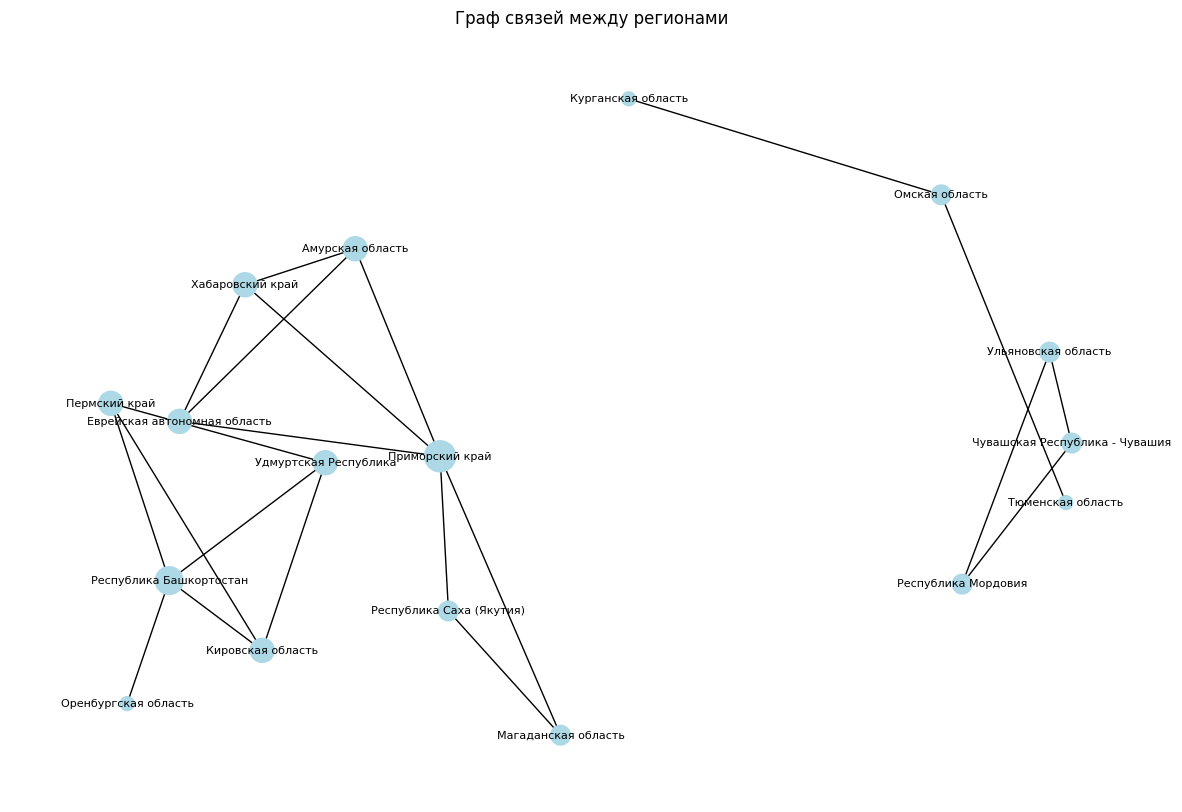

In [33]:
def plot_region_connections(region_connections):
    G = nx.Graph()
    
    for (r1, r2), weight in region_connections.items():
        G.add_edge(r1, r2, weight=weight)
    
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=1, iterations=50)
    
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                          node_size=[G.degree(node) * 100 for node in G.nodes()])
    
    nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight'] for u, v in G.edges()])
    
    nx.draw_networkx_labels(G, pos, font_size=8)
    
    plt.title("Граф связей между регионами")
    plt.axis('off')
    plt.show()

plot_region_connections(region_connections)

Создадим список, к каким федеральным округам относятся регионы в строках перечислением различных регионов

In [34]:
federal_districts = {
    'ЦФО': [],
    'СЗФО': [],
    'ПФО': [
        'Республика Башкортостан', 'Оренбургская область', 'Кировская область', 'Пермский край', 
        'Удмуртская Республика', 'Республика Мордовия', 'Ульяновская область', 
        'Чувашская Республика - Чувашия'
    ],
    'УФО': [
       'Тюменская область', 'Курганская область'
    ],
    'СФО': [
        'Омская область'
    ],
    'ДФО': [
        'Еврейская автономная область', 'Приморский край', 'Хабаровский край', 'Амурская область', 
        'Магаданская область', 'Республика Саха (Якутия)'
    ],
    'ЮФО': [],
    'СКФО': []
}

In [42]:
def analyze_geographic_patterns(region_connections):
    district_connections = {district: 0 for district in federal_districts.keys()}
    cross_district_pairs = {}
    
    for (r1, r2), count in region_connections.items():
        district1 = None
        district2 = None
        
        for district, regions in federal_districts.items():
            if r1 in regions:
                district1 = district
            if r2 in regions:
                district2 = district
        
        if district1 and district2:
            if district1 == district2:
                district_connections[district1] += count
            else:
                pair = tuple(sorted([district1, district2]))
                if pair not in cross_district_pairs:
                    cross_district_pairs[pair] = []
                cross_district_pairs[pair].append((r1, r2))
    
    return district_connections, cross_district_pairs

district_connections, cross_district_pairs = analyze_geographic_patterns(region_connections)

In [43]:
print("Связи внутри федеральных округов:")
for district, count in district_connections.items():
    print(f"{district}: {count} связей")

Связи внутри федеральных округов:
ЦФО: 0 связей
СЗФО: 0 связей
ПФО: 10 связей
УФО: 0 связей
СФО: 0 связей
ДФО: 9 связей
ЮФО: 0 связей
СКФО: 0 связей


In [45]:
print("Связи между регионами разных округов:")
for (dist1, dist2), connections in cross_district_pairs.items():
    print(f"\n{dist1} <-> {dist2}:")
    for r1, r2 in connections:
        print(f"  {r1} <-> {r2}")

Связи между регионами разных округов:

СФО <-> УФО:
  Омская область <-> Тюменская область
  Курганская область <-> Омская область


In [47]:
region_participation = {}
for (r1, r2), count in region_connections.items():
    region_participation[r1] = region_participation.get(r1, 0) + count
    region_participation[r2] = region_participation.get(r2, 0) + count

print("Топ-10 регионов, чаще всего участвующих в комбинациях:")
sorted_participation = sorted(region_participation.items(), key=lambda x: x[1], reverse=True)
for region, count in sorted_participation[:10]:
    print(f"{region}: {count} раз")

Топ-10 регионов, чаще всего участвующих в комбинациях:
Приморский край: 5 раз
Республика Башкортостан: 4 раз
Еврейская автономная область: 3 раз
Хабаровский край: 3 раз
Амурская область: 3 раз
Кировская область: 3 раз
Пермский край: 3 раз
Удмуртская Республика: 3 раз
Омская область: 2 раз
Магаданская область: 2 раз


Есть четкая концентрация связей в двух округах: ПФО - 10 связей и ДФО - 9 связей, получили наибольную активность в регионах с развитой промышленностью, также здесь можно сказать, что географическая близость в целом играет важную роль в формировании связей

Взаимосвязь, конечно, есть, но это 7 стоок из 319342 строк (0.002% данных), остальные случаи - это потворения несколько раз одного и того же региона, которые легко обрабатываются. Поэтому нет смысла создавать дополнительные признаки, для этих 7 строк просто выберем один регион

Можно предположить, что наиболее важный регион среди указанных в строке может определяться, исходя из его географического положения среди других регионов в стоке и частоты встречаемости

In [51]:
region_coordinates = {
        'Республика Башкортостан': (54.235, 56.167),
        'Оренбургская область': (52.023, 54.766),
        'Хабаровский край': (48.481, 135.071),
        'Амурская область': (50.278, 127.539),
        'Приморский край': (43.116, 131.882),
        'Еврейская автономная область': (48.786, 132.936),
        'Пермский край': (58.010, 56.229),
        'Кировская область': (58.603, 49.668),
        'Удмуртская Республика': (56.852, 53.206),
        'Тюменская область': (57.153, 65.542),
        'Омская область': (54.988, 73.368),
        'Курганская область': (55.441, 65.115),
        'Магаданская область': (59.568, 150.808),
        'Республика Саха (Якутия)': (62.028, 129.732),
        'Чувашская Республика - Чувашия': (56.132, 47.244),
        'Ульяновская область': (54.318, 48.383),
        'Республика Мордовия': (54.187, 45.183)
    }

In [57]:
def calculate_region_score(region, regions_list, coords, region_counts):
    center_lat = sum(lat for lat, _ in coords) / len(coords)
    center_lon = sum(lon for _, lon in coords) / len(coords)
    
    dist = ((region_coordinates[region][0] - center_lat)**2 + 
            (region_coordinates[region][1] - center_lon)**2)
    max_dist = max(((r_coord[0] - center_lat)**2 + (r_coord[1] - center_lon)**2) 
                  for r_coord in coords)
    norm = dist / max_dist if max_dist > 0 else 1
    distance_score = 1 - norm
    
    freq = region_counts.get(region, 0)
    max_freq = max(region_counts.get(r, 0) for r in regions_list)
    frequency_score = freq / max_freq if max_freq > 0 else 0
    
    return 0.5 * distance_score + 0.5 * frequency_score

def process_multi_region(regions, df):
    regions_list = [r.strip() for r in regions.split(';')]
    
    if len(regions_list) != len(set(regions_list)):
        return max(set(regions_list), key=regions_list.count)
    
    region_counts = df['Регион поставки'].value_counts()
    coords = [region_coordinates[r] for r in regions_list]
    
    return max(regions_list, key=lambda r: calculate_region_score(r, regions_list, coords, region_counts))


In [62]:
def clean_regions(df):
    df = df.copy()
    mask = df['Регион поставки'].str.contains(';', na=False)
    original_regions = df.loc[mask, 'Регион поставки'].copy()
    
    df.loc[mask, 'Регион поставки'] = df[mask]['Регион поставки'].apply(
        lambda x: process_multi_region(x, df)
    )
    
    print("Результаты обработки мультирегиональных строк:")
    for orig, new in zip(original_regions, df.loc[mask, 'Регион поставки']):
        print(f"Было: {orig}")
        print(f"Стало: {new}")
        print("-" * 50)
    return df

df_cleaned = clean_regions(df)

Результаты обработки мультирегиональных строк:
Было: Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан
Стало: Республика Башкортостан
--------------------------------------------------
Было: Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан; Республика Башкортостан
Стало: Республика Башкортостан
--------------------------------------------------
Было: Республика Башкортостан; Республика Башкортостан
Стало: Республика Башкортостан
--------------------------------------------------
Было: Нижегородская область; Нижегородская область; Нижегородская область; Нижегородская область
Стало: Нижегородская область
--------------------------------------------------
Было: Республика Башкортостан; Оренбургская область
Стало: Респуб

In [64]:
print(df_cleaned['Регион поставки'].unique())

['Волгоградская область' 'Чукотский автономный округ' 'Пензенская область'
 'Кировская область' 'Республика Крым' 'Республика Башкортостан'
 'Новосибирская область' 'Республика Коми' 'Орловская область'
 'Краснодарский край' 'Тюменская область' 'Москва' 'Липецкая область'
 'Ямало-Ненецкий автономный округ (Тюменская область)'
 'Ханты-Мансийский автономный округ - Югра (Тюменская область)'
 'Омская область' 'Республика Хакасия' 'Иркутская область'
 'Самарская область' 'Ставропольский край' 'Архангельская область'
 'Томская область' 'Саратовская область' 'Смоленская область'
 'Московская область' 'Алтайский край' 'Челябинская область'
 'Республика Саха (Якутия)' 'Свердловская область'
 'Республика Татарстан (Татарстан)' 'Кемеровская область - Кузбасс'
 'Республика Бурятия' 'Севастополь' 'Санкт-Петербург' 'Приморский край'
 'Забайкальский край' 'Оренбургская область' 'Нижегородская область'
 'Пермский край' 'Ярославская область' 'Мурманская область'
 'Брянская область' 'Калужская область'